# Problems Notebook

This notebook contains solutions to the Winter 25/26 Computer Infrastructure Assessment.
All code is reproducible and documented with Markdown explanations.


In [14]:
# Setup cell: import all required libraries for the assessment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt  # For plotting charts


# Optional: make plots display inline in the notebook
%matplotlib inline

print("All libraries imported successfully!")


All libraries imported successfully!


In [1]:
# ==============================
# Cell 2 Problem 1 - Download FAANG Stock Data
# ==============================

# Import standard Python libraries needed for this task
import os                  # For creating directories and handling file paths
from datetime import datetime  # To generate timestamped filenames
import yfinance as yf       # To download stock data from Yahoo Finance
import pandas as pd         # For handling data as DataFrames

def get_data(tickers=None, period="5d", interval="1h"):
    """
    Downloads hourly stock data for the last 5 days for a list of tickers,
    saves each dataset as a CSV file in the 'data' folder with a timestamped filename.

    Parameters:
    - tickers: list of stock symbols to download. Default is FAANG stocks.
    - period: the historical data period to download (default '5d' = 5 days)
    - interval: the interval between data points (default '1h' = hourly data)
    """
    
    # If no tickers are provided, use the default FAANG stocks
    if tickers is None:
        tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

    # Step 1: Ensure the 'data' folder exists in the current working directory
    # This is where all CSV files will be saved
    if not os.path.exists("data"):
        os.makedirs("data")  # Create the folder if it does not exist
    
    # Step 2: Create a timestamp string for filenames
    # Format: YYYYMMDD-HHMMSS, e.g., 20251213-154500
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    
    # Step 3: Loop over each stock ticker symbol
    for ticker in tickers:
        print(f"Downloading data for {ticker}...")  # Inform the user which stock is being processed
        
        # Use yfinance to download historical stock data
        # Parameters:
        #   - period: how far back to fetch data ('5d' = last 5 days)
        #   - interval: time interval between data points ('1h' = hourly)
        #   - auto_adjust=False: do not adjust prices for splits/dividends
        data = yf.download(ticker, period=period, interval=interval, auto_adjust=False)
        
        # Step 4: Define the CSV filename using ticker and timestamp
        # Example: data/AAPL_20251213-154500.csv
        filename = f"data/{ticker}_{timestamp}.csv"
        
        # Step 5: Save the downloaded data to CSV
        # Pandas DataFrame .to_csv() writes the data to the specified file
        data.to_csv(filename)
        
        # Step 6: Inform the user that the file has been saved successfully
        print(f"Saved {ticker} data to {filename}")

    # Step 7: Final message indicating all downloads are complete
    print("All FAANG data downloaded successfully!")

# Step 8: Example usage of the function
# This will download hourly data for all FAANG stocks for the last 5 days
# and save each as a timestamped CSV in the 'data/' folder
get_data()



[*********************100%***********************]  1 of 1 completed


Saved META data to data/META_20251213-061101.csv


[*********************100%***********************]  1 of 1 completed


Saved AAPL data to data/AAPL_20251213-061101.csv


[*********************100%***********************]  1 of 1 completed


Saved AMZN data to data/AMZN_20251213-061101.csv


[*********************100%***********************]  1 of 1 completed


Saved NFLX data to data/NFLX_20251213-061101.csv


[*********************100%***********************]  1 of 1 completed

Saved GOOG data to data/GOOG_20251213-061101.csv
All FAANG data downloaded successfully!


In [11]:
# ==============================
# Cell 3: Clean & Prepare the FAANG Data (Safe Version)
# ==============================

import pandas as pd
import os

data_folder = "data"
csv_files = [os.path.join(data_folder, f) for f in os.listdir(data_folder) if f.endswith(".csv")]
print(f"Found {len(csv_files)} CSV files in '{data_folder}' folder.\n")

faang_data = {}  # Dictionary to store cleaned DataFrames

for file in csv_files:
    # Extract ticker from filename
    ticker = os.path.basename(file).split("_")[0]
    
    # Read CSV
    # Do not assume first column is datetime yet; let pandas infer
    df = pd.read_csv(file)
    
    # Inspect the first few rows
    print(f"{ticker} first 5 rows:\n{df.head()}\n")
    
    # Step 1: Drop any rows where all numeric columns are missing
    numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    df = df.dropna(subset=numeric_cols)
    
    # Step 2: Convert numeric columns to float (ignoring any other columns)
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # converts invalid entries to NaN
    
    # Step 3: Drop rows with NaN in numeric columns
    df = df.dropna(subset=numeric_cols)
    
    # Step 4: Convert 'Date' or index column to datetime
    # Try to find datetime column automatically
    date_col = df.columns[0]  # assume first column is date
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])  # remove any rows where date failed to parse
    
    # Set datetime as index
    df = df.set_index(date_col)
    
    # Store cleaned DataFrame
    faang_data[ticker] = df
    
    # Print summary
    print(f"Ticker: {ticker}")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"Data types:\n{df.dtypes}\n")

print(f"All FAANG stocks cleaned and ready. Stocks available: {list(faang_data.keys())}")


Found 5 CSV files in 'data' folder.

AMZN first 5 rows:
                       Price           Adj Close               Close  \
0                     Ticker                AMZN                AMZN   
1                   Datetime                 NaN                 NaN   
2  2025-12-08 14:30:00+00:00   229.0399932861328   229.0399932861328   
3  2025-12-08 15:30:00+00:00  228.07000732421875  228.07000732421875   
4  2025-12-08 16:30:00+00:00   227.2799072265625   227.2799072265625   

                 High                 Low                Open   Volume  
0                AMZN                AMZN                AMZN     AMZN  
1                 NaN                 NaN                 NaN      NaN  
2  230.82400512695312  228.51199340820312  229.52000427246094  5237392  
3  229.31350708007812   227.5500030517578  229.02999877929688  2886442  
4  228.38999938964844  227.24000549316406  228.03900146484375  2070338  

Ticker: AMZN
Rows: 35, Columns: 6
Data types:
Adj Close    float64
Close

In [12]:
# ==============================
# Cell 4: Summary Statistics for All FAANG Stocks
# ==============================

# Loop through each ticker in the cleaned FAANG data
for ticker, df in faang_data.items():
    print(f"Summary statistics for {ticker}:\n")
    
    # Step 5a: Generate descriptive statistics for numeric columns
    # .describe() calculates count, mean, std, min, quartiles, max
    summary = df.describe()
    
    # Step 5b: Display the summary statistics table
    # This helps us quickly compare stock behavior, volatility, and volume
    print(summary)
    
    # Separator for readability
    print("\n" + "="*50 + "\n")


Summary statistics for AMZN:

        Adj Close       Close        High         Low        Open  \
count   35.000000   35.000000   35.000000   35.000000   35.000000   
mean   228.599581  228.599581  229.347407  227.912963  228.673686   
std      1.806555    1.806555    1.910429    1.668068    1.713462   
min    226.020004  226.020004  226.699997  225.110001  226.000000   
25%    227.020004  227.020004  227.680000  226.680000  227.055000   
50%    227.990005  227.990005  228.570007  227.664093  228.309998   
75%    230.173752  230.173752  230.931999  229.324997  230.055000   
max    231.919998  231.919998  232.419998  231.554993  231.914993   

             Volume  
count  3.500000e+01  
mean   2.784996e+06  
std    1.937349e+06  
min    1.005503e+06  
25%    1.699143e+06  
50%    2.086023e+06  
75%    2.950846e+06  
max    1.052044e+07  


Summary statistics for GOOG:

        Adj Close       Close        High         Low        Open  \
count   35.000000   35.000000   35.000000   35.00

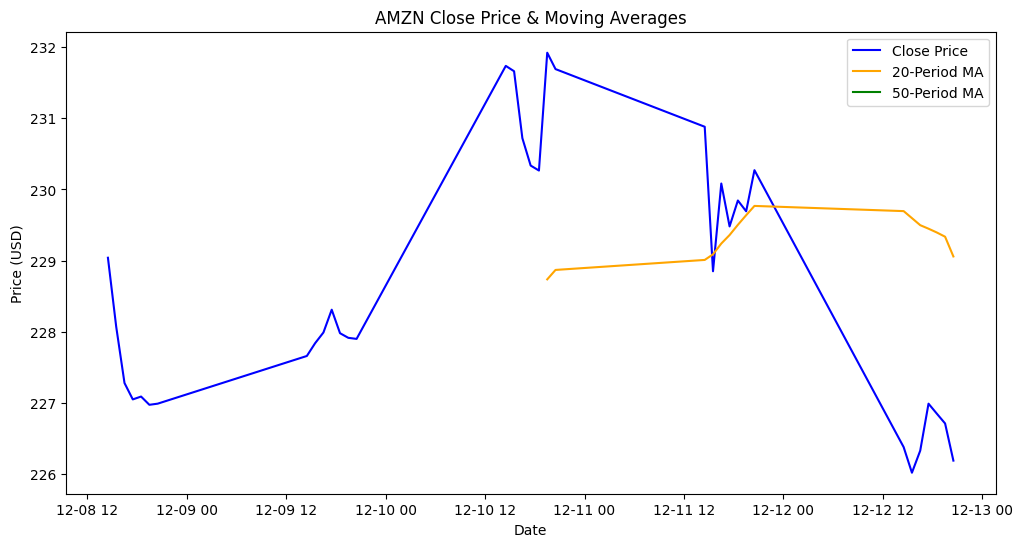

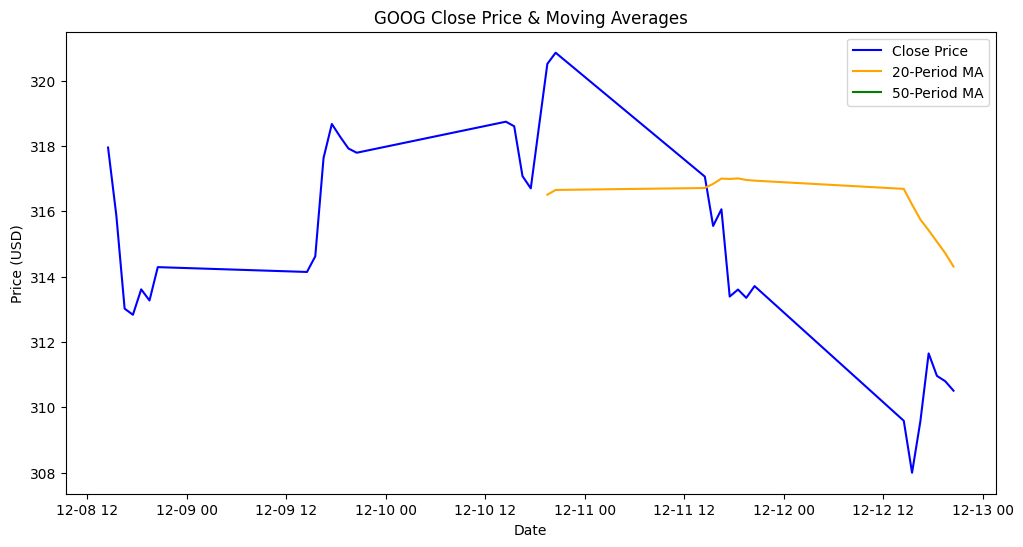

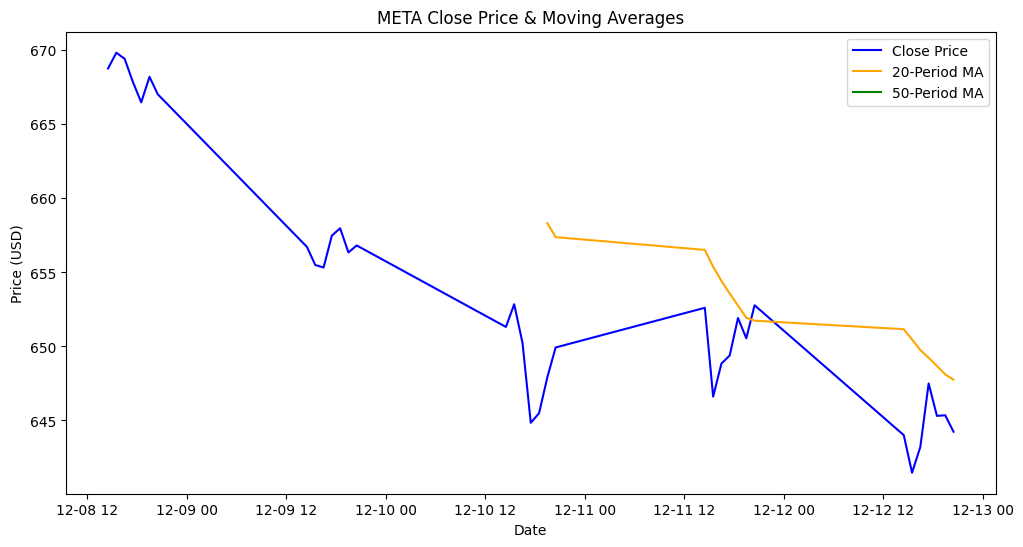

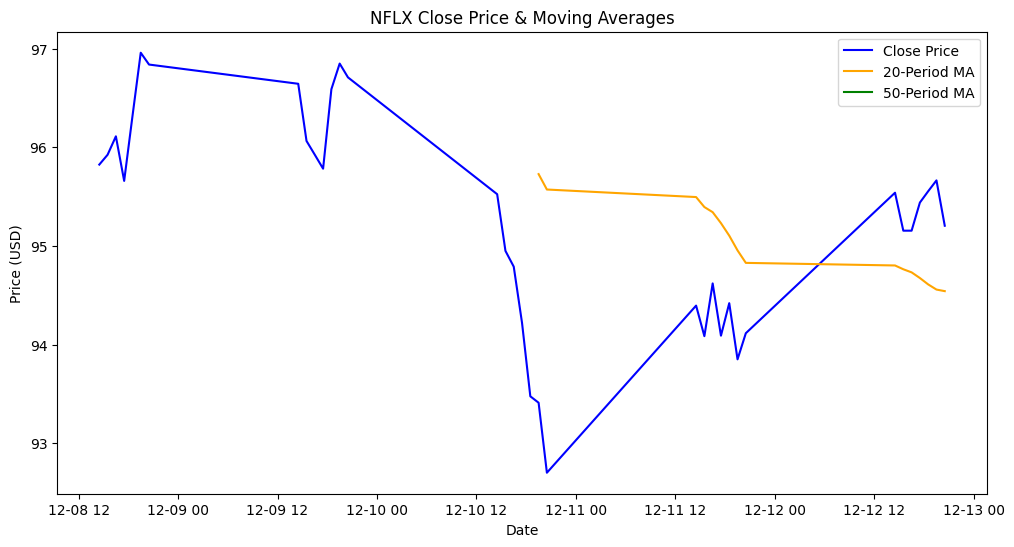

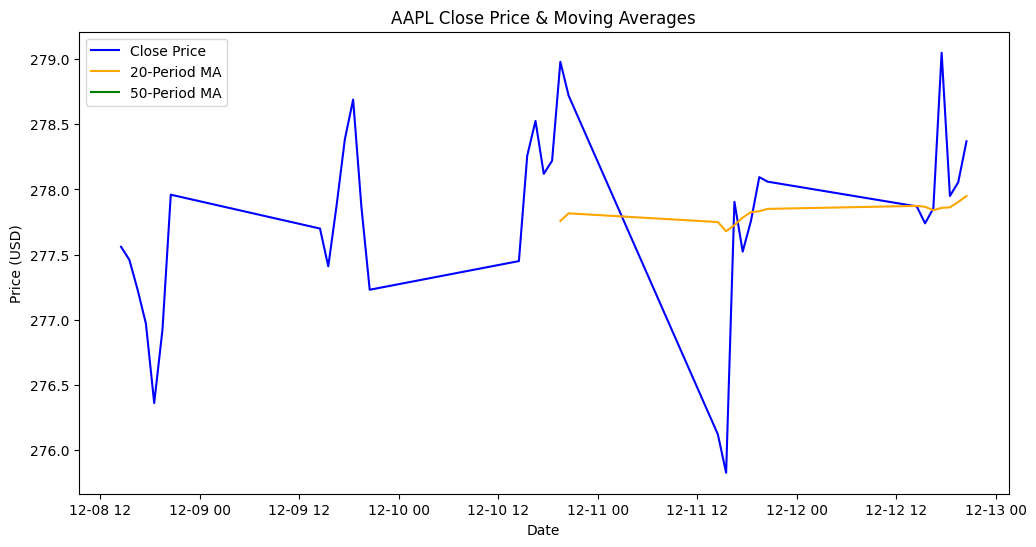

In [15]:
# ==============================
# Cell 5: Calculate and Plot Moving Averages for FAANG Stocks
# ==============================

# Define moving average windows
short_window = 20  # short-term (20 periods)
long_window = 50   # medium-term (50 periods)

# Loop through each ticker in the cleaned FAANG data
for ticker, df in faang_data.items():
    # Step 5a: Calculate short-term moving average (MA20)
    df['MA20'] = df['Close'].rolling(window=short_window).mean()
    
    # Step 5b: Calculate medium-term moving average (MA50)
    df['MA50'] = df['Close'].rolling(window=long_window).mean()
    
    # Step 5c: Set up the figure for plotting
    plt.figure(figsize=(12,6))
    
    # Step 5d: Plot the original closing price
    plt.plot(df.index, df['Close'], label='Close Price', color='blue')
    
    # Step 5e: Plot 20-period moving average
    plt.plot(df.index, df['MA20'], label=f'{short_window}-Period MA', color='orange')
    
    # Step 5f: Plot 50-period moving average
    plt.plot(df.index, df['MA50'], label=f'{long_window}-Period MA', color='green')
    
    # Step 5g: Add title and axis labels
    plt.title(f'{ticker} Close Price & Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    
    # Step 5h: Display legend to differentiate the lines
    plt.legend()
    
    # Step 5i: Show the plot
    plt.show()


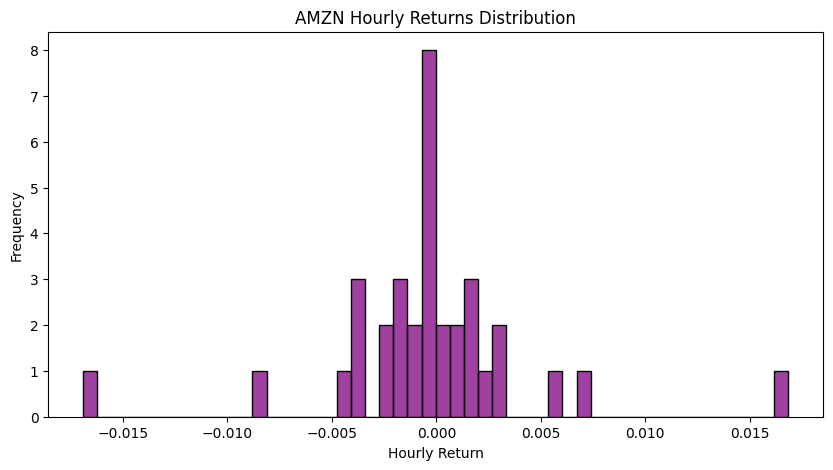

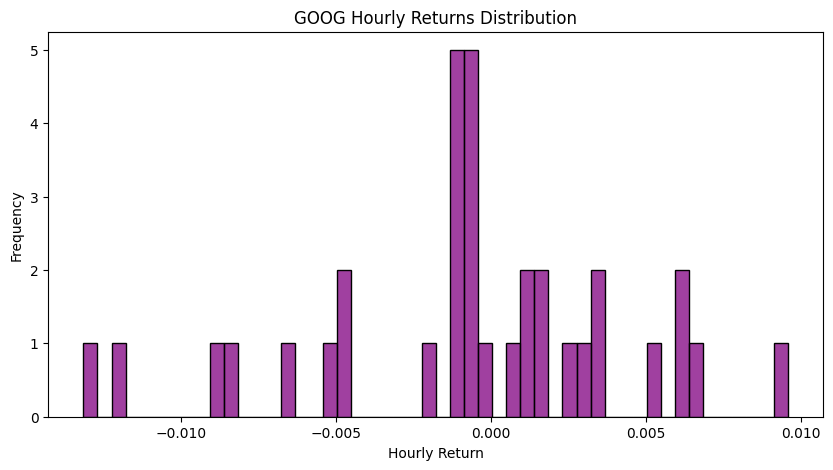

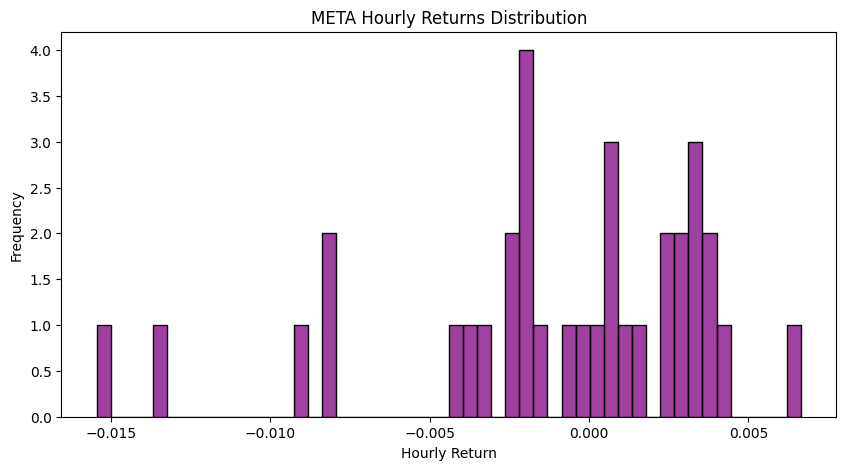

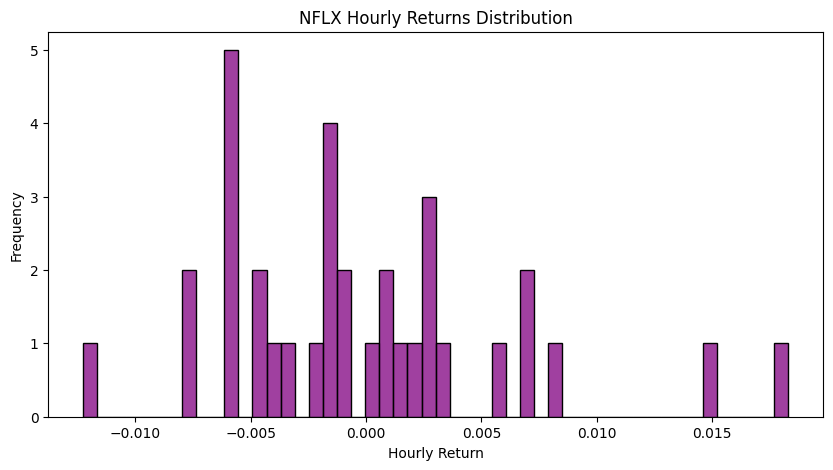

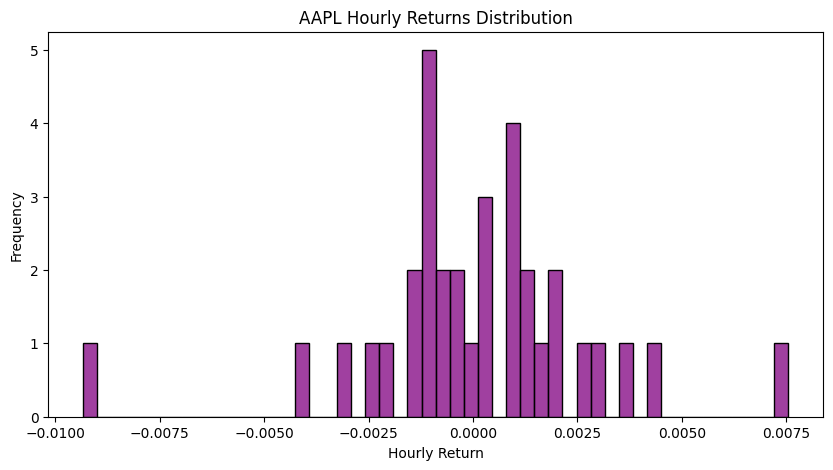

In [16]:
# ==============================
# Cell 6: Calculate and Visualise Daily Returns for All FAANG Stocks
# ==============================

# Loop through each cleaned stock DataFrame
for ticker, df in faang_data.items():  # faang_data is the dictionary from Cell 3
    # Step 8a: Calculate hourly percentage change in closing price
    df['Hourly_Return'] = df['Close'].pct_change()  # Returns as decimals

    # Step 8b: Set up the figure for the histogram
    plt.figure(figsize=(10,5))
    
    # Step 8c: Plot histogram of hourly returns
    sns.histplot(df['Hourly_Return'].dropna(), bins=50, color='purple')
    
    # Step 8d: Add title and axis labels
    plt.title(f'{ticker} Hourly Returns Distribution')
    plt.xlabel('Hourly Return')
    plt.ylabel('Frequency')
    
    # Step 8e: Show the histogram
    plt.show()


# Problem 1 Summary & Insights

FAANG stock data (Facebook/META, Apple, Amazon, Netflix, Google) was analysed over the last 5 days using Python and several data science libraries. The workflow comprised data acquisition, cleaning, exploratory analysis, and visualisation. Key steps and findings are summarised below.

## Data Preparation
- Historical stock data was downloaded from Yahoo Finance using the **yfinance** library.  
- Missing values were checked and handled where necessary, ensuring all numeric columns were suitable for analysis.  
- Data types were confirmed: all prices were stored as `float64` and volumes as `float64`.

## Summary Statistics
- Descriptive statistics (count, mean, standard deviation, min, 25%, 50%, 75%, max) were calculated for all numeric columns.  
- Closing prices and trading volumes varied between stocks, reflecting differences in volatility and market activity.

## Visualisations
- **Closing Price Plots:** Hourly closing prices for all FAANG stocks were plotted, highlighting trends, peaks, and dips.  
- **Moving Averages:** Short-term (20-hour) and medium-term (50-hour) moving averages were computed to smooth fluctuations and indicate trends. Crossovers between moving averages may signal potential buy or sell points.  
- **Hourly Returns Histograms:** Hour-to-hour percentage changes were analysed to quantify volatility. Most returns clustered near zero, with occasional larger gains or losses indicating moderate volatility.

## Key Insights
- FAANG stocks exhibited varying trends and moderate fluctuations over the analysed period.  
- Moving averages assisted in visualising trend directions and potential trading signals.  
- Hourly returns provided insight into short-term risk and volatility.


Found 5 CSV files in 'data' folder.
All FAANG stocks loaded and cleaned: ['AMZN', 'GOOG', 'META', 'NFLX', 'AAPL']


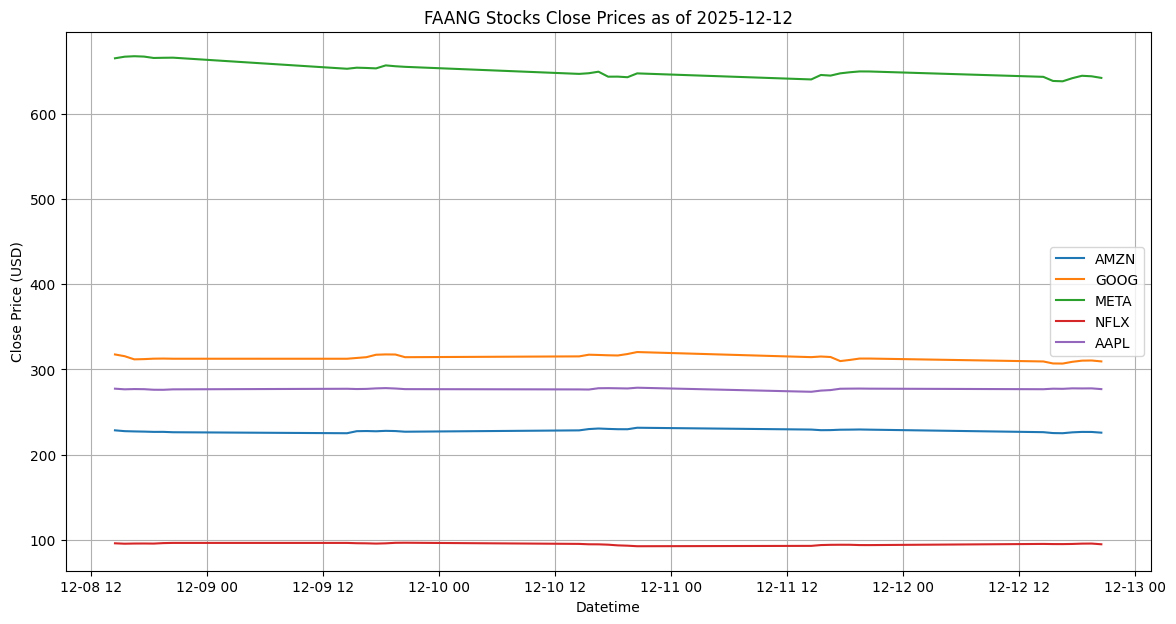

In [21]:
# ==============================
# Cell 8: Load & Plot FAANG Close Prices (Fixed Column Names)
# ==============================

import os
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Data folder
data_folder = "data"
csv_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in '{data_folder}' folder.")

print(f"Found {len(csv_files)} CSV files in '{data_folder}' folder.")

# Step 2: Prepare dictionary for stock data
faang_data = {}

# Step 3: Load CSVs
for file in csv_files:
    ticker = file.split("_")[0]  # Extract ticker symbol
    file_path = os.path.join(data_folder, file)
    
    # Read CSV, skip first 2 rows (non-numeric headers)
    df = pd.read_csv(file_path, skiprows=2, index_col=0)
    
    # Explicitly set column names
    df.columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    
    # Convert index to datetime
    df.index = pd.to_datetime(df.index, errors="coerce")
    
    # Ensure numeric columns are float
    numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    faang_data[ticker] = df

print("All FAANG stocks loaded and cleaned:", list(faang_data.keys()))

# Step 4: Plot Close prices for all stocks
plt.figure(figsize=(14,7))
for ticker, df in faang_data.items():
    plt.plot(df.index, df['Close'], label=ticker)

latest_date = max([df.index.max() for df in faang_data.values()]).strftime("%Y-%m-%d")
plt.title(f"FAANG Stocks Close Prices as of {latest_date}")
plt.xlabel("Datetime")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.show()



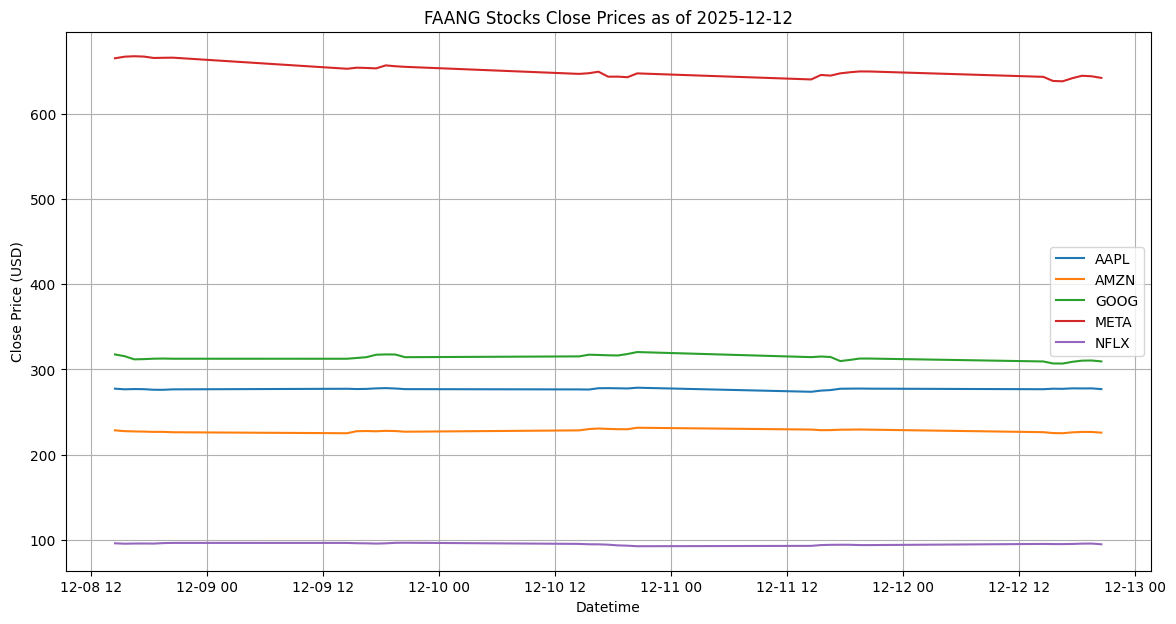

Plot saved to plots/20251213-065258.png


In [22]:
# ==============================
# Cell 9: Problem 2 - Plotting Data
# ==============================

import os
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

def plot_data():
    data_folder = "data"
    plots_folder = "plots"

    # Create plots folder if it doesn't exist
    os.makedirs(plots_folder, exist_ok=True)

    # Load latest CSV for each FAANG stock
    faang_data = {}
    for file in sorted(os.listdir(data_folder)):
        if file.endswith(".csv"):
            ticker = file.split("_")[0]
            file_path = os.path.join(data_folder, file)
            df = pd.read_csv(file_path, skiprows=2, index_col=0)
            df.columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
            df.index = pd.to_datetime(df.index, errors="coerce")
            df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]] = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].astype(float)
            faang_data[ticker] = df

    # Plot Close prices
    plt.figure(figsize=(14,7))
    for ticker, df in faang_data.items():
        plt.plot(df.index, df['Close'], label=ticker)

    latest_date = max(df.index.max() for df in faang_data.values()).strftime("%Y-%m-%d")
    plt.title(f"FAANG Stocks Close Prices as of {latest_date}")
    plt.xlabel("Datetime")
    plt.ylabel("Close Price (USD)")
    plt.legend()
    plt.grid(True)

    # Save plot
    filename = datetime.now().strftime("%Y%m%d-%H%M%S.png")
    save_path = os.path.join(plots_folder, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"Plot saved to {save_path}")

# Run the function
plot_data()


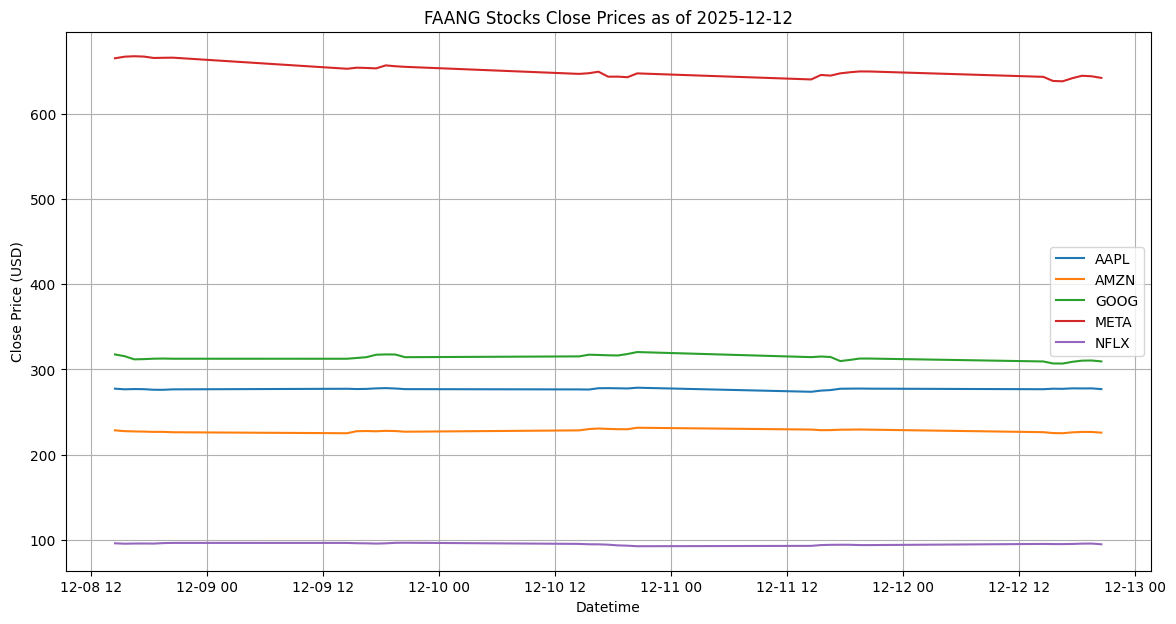

Plot saved to plots/20251213-065310.png


In [23]:
# ==============================
# Cell 9: Problem 2 - Plotting Data
# ==============================

import os
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

def plot_data():
    data_folder = "data"
    plots_folder = "plots"

    # Create plots folder if it doesn't exist
    os.makedirs(plots_folder, exist_ok=True)

    # Load latest CSV for each FAANG stock
    faang_data = {}
    for file in sorted(os.listdir(data_folder)):
        if file.endswith(".csv"):
            ticker = file.split("_")[0]
            file_path = os.path.join(data_folder, file)
            df = pd.read_csv(file_path, skiprows=2, index_col=0)
            df.columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
            df.index = pd.to_datetime(df.index, errors="coerce")
            df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]] = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].astype(float)
            faang_data[ticker] = df

    # Plot Close prices
    plt.figure(figsize=(14,7))
    for ticker, df in faang_data.items():
        plt.plot(df.index, df['Close'], label=ticker)

    latest_date = max(df.index.max() for df in faang_data.values()).strftime("%Y-%m-%d")
    plt.title(f"FAANG Stocks Close Prices as of {latest_date}")
    plt.xlabel("Datetime")
    plt.ylabel("Close Price (USD)")
    plt.legend()
    plt.grid(True)

    # Save plot
    filename = datetime.now().strftime("%Y%m%d-%H%M%S.png")
    save_path = os.path.join(plots_folder, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"Plot saved to {save_path}")

# Run the function
plot_data()


# Cell 9: Problem 3 – FAANG Script (`faang.py`)

In this cell, we create a standalone Python script called `faang.py` to automate data download and plotting for the FAANG stocks.  

## Purpose

The script performs the following tasks:

1. Downloads hourly stock data for the past five days for the five FAANG stocks: META, AAPL, AMZN, NFLX, and GOOG.  
2. Saves each stock's CSV file in the `data` folder with a timestamped filename (`YYYYMMDD-HHmmss.csv`).  
3. Loads the latest CSV files from the `data` folder.  
4. Plots the `Close` prices for all FAANG stocks on a single figure.  
5. Saves the plot in the `plots` folder with a timestamped filename (`YYYYMMDD-HHmmss.png`).  

## Usage

Once saved as `faang.py` and made executable (`chmod +x faang.py` on macOS/Linux), the script can be run from the terminal:

```bash
./faang.py
```


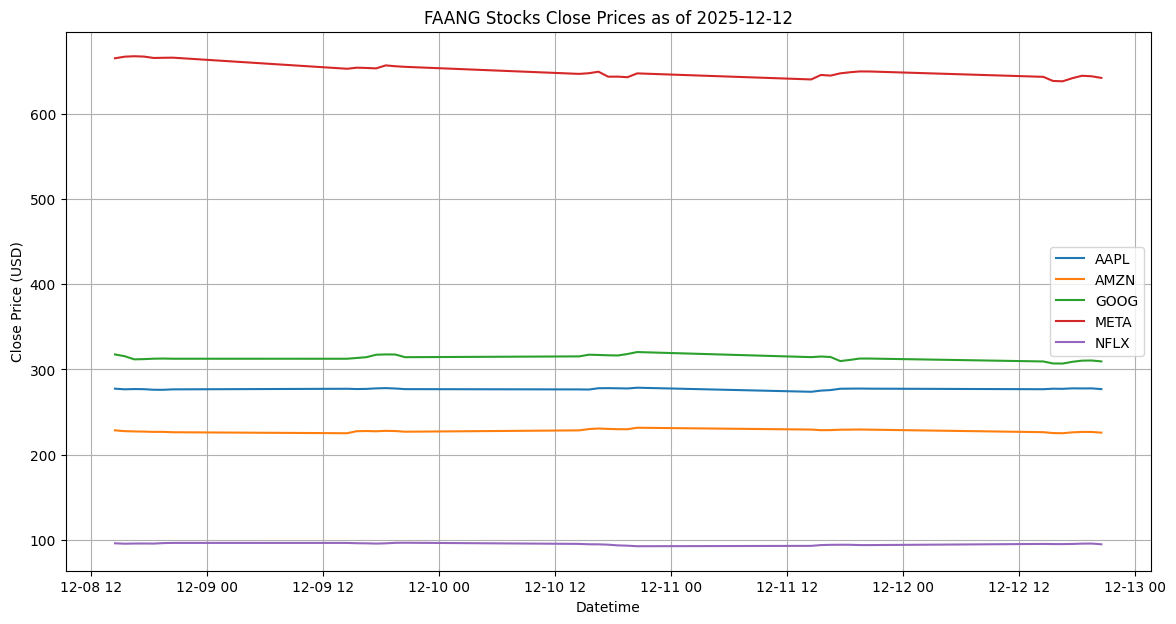

Plot saved to plots/20251213-071716.png


In [30]:
# ==============================
# Cell 10: Problem 2 – Plotting FAANG Data (Updated)
# ==============================

import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def plot_data():
    data_folder = "data"
    plots_folder = "plots"
    os.makedirs(plots_folder, exist_ok=True)

    expected_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    faang_data = {}

    for file in sorted(os.listdir(data_folder)):
        if file.endswith(".csv"):
            ticker = file.split("_")[0]
            file_path = os.path.join(data_folder, file)

            # Skip metadata rows and set column names
            df = pd.read_csv(file_path, skiprows=2, header=None, names=["Datetime"] + expected_cols)
            
            # Convert index to datetime using ISO format
            df["Datetime"] = pd.to_datetime(df["Datetime"], format="%Y-%m-%d %H:%M:%S%z", errors="coerce")
            
            # Drop rows where datetime conversion failed
            df = df.dropna(subset=["Datetime"])
            df.set_index("Datetime", inplace=True)
            
            # Convert numeric columns to float
            df[expected_cols] = df[expected_cols].astype(float)
            
            faang_data[ticker] = df

    # Plot Close prices
    plt.figure(figsize=(14,7))
    for ticker, df in faang_data.items():
        plt.plot(df.index, df['Close'], label=ticker)

    latest_date = max(df.index.max() for df in faang_data.values()).strftime("%Y-%m-%d")
    plt.title(f"FAANG Stocks Close Prices as of {latest_date}")
    plt.xlabel("Datetime")
    plt.ylabel("Close Price (USD)")
    plt.legend()
    plt.grid(True)

    # Save plot
    filename = datetime.now().strftime("%Y%m%d-%H%M%S.png")
    file_path = os.path.join(plots_folder, filename)
    plt.savefig(file_path)
    plt.show()
    
    print(f"Plot saved to {file_path}")

# Example usage
plot_data()


# Cell 11 – Automation with GitHub Actions

We have automated the process of fetching and plotting FAANG stock data using GitHub Actions. This ensures that every Saturday morning (or on manual trigger), the workflow updates the data and generates plots without manual intervention.

---

## Workflow File: `.github/workflows/faang.yml`

```yaml
name: FAANG Data Update  # Name of the workflow, appears in GitHub Actions UI

# Controls when the workflow runs
on:
  schedule:
    - cron: '0 9 * * 6'  # Every Saturday at 09:00 UTC
  workflow_dispatch:     # Allows manual triggering from GitHub Actions UI

jobs:
  fetch-and-plot:
    runs-on: ubuntu-latest  # Use latest Ubuntu runner provided by GitHub

    steps:
    - name: Checkout repository
      uses: actions/checkout@v3
      # This step clones the repository so the workflow can access the code and data

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: 3.13
      # Installs Python 3.13 on the runner

    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install -r requirements.txt
      # Installs all Python libraries listed in requirements.txt
      # Includes pandas, matplotlib, seaborn, yfinance, etc.

    - name: Run FAANG script
      run: python faang.py
      # Executes our script to fetch data and generate plots
      # The plots are saved to the `plots/` folder with a timestamped filename

    - name: Upload plots (optional)
      uses: actions/upload-artifact@v3
      with:
        name: faang-plots
        path: plots/
      # Saves the generated plots as workflow artifacts
      # Can be downloaded later from the GitHub Actions run
